# Análise do Perfil Físico dos Elencos como Fator de Vitória nas Principais Ligas Europeias

**Autor:** Marlon Patrick Magest Filgueiras  
**Orientador:** Prof. Dr. Rodolfo Nicolay  
**Instituição:** Universidade Católica de Petrópolis  
**Curso:** Ciência de Dados e Business Intelligence  
**Ano:** 2026

---

## Perguntas centrais

> **1.** O perfil físico dos elencos — medido pelas diferenças médias de **altura**, **peso** e **idade** entre mandante e visitante — é fator associado à probabilidade de vitória no futebol europeu?
>
> **2.** Caso esse efeito exista, ele é **uniforme entre as ligas** ou varia de campeonato para campeonato?

---

**Base de dados:** *European Soccer Database* (MATHIEN, 2016) — SQLite | 11 ligas | Temporadas 2008/09 a 2015/16  
**Tabelas utilizadas:** `Match`, `Player`, `League`, `Country`  
**Excluído por design:** `Player_Attributes` (ratings subjetivos do FIFA — apenas no Apêndice)

> **Nota:** Ferramentas de IA foram usadas para correção ortográfica dos comentários e aprimoramento visual dos gráficos. Todo conteúdo analítico e as decisões metodológicas são de inteira responsabilidade do autor.

---

| Etapa | Conteúdo |
|:------|:---------|
| **0** | Dependências e configuração |
| **1** | Extração SQL, JOIN e engenharia de atributos |
| **2** | Análise exploratória (EDA) |
| **3** | Testes estatísticos formais |
| **4** | Modelagem supervisionada |
| **Apêndice** | Análise complementar com atributos FIFA |


---
## Etapa 0 — Dependências e Configuração

Importação de todas as bibliotecas e definição das constantes de estilo usadas ao longo do notebook.
A paleta de cores `CORES_RESULTADO` é definida uma única vez e reutilizada em todos os gráficos,
garantindo consistência visual.


In [2]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── Estilo visual ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

# Paleta consistente: W=vitória, D=empate, L=derrota
CORES_RESULTADO = {'W': '#1D9E75', 'D': '#888780', 'L': '#D85A30'}

# Caminho do banco SQLite
DB_PATH = 'database.sqlite'

print('Bibliotecas carregadas.')
print(f'Pandas {pd.__version__} | NumPy {np.__version__}')


Bibliotecas carregadas.
Pandas 2.2.2 | NumPy 2.0.2


---
## Etapa 1 — Extração SQL, JOIN e Engenharia de Atributos

Esta etapa constrói o dataset analítico a partir do banco SQLite.
O fluxo segue seis passos sequenciais:

1. Carga das tabelas `Match`, `Player`, `League`
2. Pré-processamento dos dados biométricos (conversão de peso libras → kg, cálculo de idade)
3. *Unpivot* das escalações (largo → longo)
4. JOIN com dados físicos individuais
5. Agregação por (partida, lado) e pivot de volta
6. Criação das variáveis de diferença e filtro de qualidade

**Decisões metodológicas:**
- Peso em libras × 0,453592 → kg
- Idade = (data_partida − data_nascimento) / 365,25 (evita acúmulo de erro em anos bissextos)
- Filtro: ≥ 9 jogadores com dados físicos por lado por partida


In [4]:
# ── 1. Carga das tabelas base ─────────────────────────────────────────────────

conn = sqlite3.connect(DB_PATH)

# Jogadores: apenas colunas biométricas objetivas
players = pd.read_sql("""
    SELECT player_api_id, birthday, height, weight
    FROM Player
    WHERE height IS NOT NULL
      AND weight IS NOT NULL
      AND birthday IS NOT NULL
""", conn)

# Partidas: escalações + resultado + contexto
match_cols = """
    id AS match_id, league_id, season, date,
    home_team_api_id, away_team_api_id,
    home_team_goal, away_team_goal,
    home_player_1,  home_player_2,  home_player_3,
    home_player_4,  home_player_5,  home_player_6,
    home_player_7,  home_player_8,  home_player_9,
    home_player_10, home_player_11,
    away_player_1,  away_player_2,  away_player_3,
    away_player_4,  away_player_5,  away_player_6,
    away_player_7,  away_player_8,  away_player_9,
    away_player_10, away_player_11
"""
matches = pd.read_sql(f'SELECT {match_cols} FROM Match', conn)

# Ligas com nome do país
leagues = pd.read_sql("""
    SELECT l.id AS league_id, l.name AS league_name, c.name AS country_name
    FROM League l JOIN Country c ON c.id = l.country_id
""", conn)

conn.close()
print(f'Partidas: {len(matches):,} | Jogadores: {len(players):,} | Ligas: {len(leagues)}')


Partidas: 25,979 | Jogadores: 11,060 | Ligas: 11


In [5]:
# ── 2. Pré-processamento dos jogadores ────────────────────────────────────────

# Peso: libras → kg
players['weight_kg'] = (players['weight'] * 0.453592).round(1)

# Altura já está em cm
players.rename(columns={'height': 'height_cm'}, inplace=True)

# Data de nascimento para datetime
players['birthday'] = pd.to_datetime(players['birthday'])
players = players[['player_api_id', 'birthday', 'height_cm', 'weight_kg']]

print('Pré-processamento concluído.')
print(players[['height_cm', 'weight_kg']].describe().round(2))


Pré-processamento concluído.
       height_cm  weight_kg
count   11060.00   11060.00
mean      181.87      76.36
std         6.37       6.80
min       157.48      53.10
25%       177.80      72.10
50%       182.88      76.20
75%       185.42      81.20
max       208.28     110.20


In [6]:
# ── 3. Unpivot das escalações: largo → longo ──────────────────────────────────
# Cada partida tem 22 colunas de jogadores (11 por lado).
# Transformamos para uma linha por jogador por partida para possibilitar o JOIN.

home_cols = [f'home_player_{i}' for i in range(1, 12)]
away_cols = [f'away_player_{i}' for i in range(1, 12)]
id_vars   = ['match_id', 'league_id', 'season', 'date',
             'home_team_api_id', 'away_team_api_id',
             'home_team_goal', 'away_team_goal']

home_long = matches[id_vars + home_cols].melt(
    id_vars=id_vars, value_vars=home_cols,
    var_name='slot', value_name='player_api_id')
home_long['side'] = 'home'

away_long = matches[id_vars + away_cols].melt(
    id_vars=id_vars, value_vars=away_cols,
    var_name='slot', value_name='player_api_id')
away_long['side'] = 'away'

lineups = pd.concat([home_long, away_long], ignore_index=True)
lineups = lineups.dropna(subset=['player_api_id'])
lineups['player_api_id'] = lineups['player_api_id'].astype(int)
print(f'Linhas após unpivot: {len(lineups):,}')


Linhas após unpivot: 542,281


In [7]:
# ── 4. JOIN com biométricos — cálculo de idade exata na data da partida ────────
# Divisor 365,25 evita acúmulo de erro em anos bissextos.

lineups = lineups.merge(players, on='player_api_id', how='left')
lineups['date'] = pd.to_datetime(lineups['date'])
lineups['age']  = ((lineups['date'] - lineups['birthday']).dt.days / 365.25).round(1)

total, com_dados = len(lineups), lineups['height_cm'].notna().sum()
print(f'Cobertura de dados físicos: {com_dados:,} / {total:,} ({100*com_dados/total:.1f}%)')


Cobertura de dados físicos: 542,281 / 542,281 (100.0%)


In [8]:
# ── 5. Agregação por (partida, lado) e pivot home/away ────────────────────────

agg = (
    lineups
    .groupby(id_vars + ['side'])
    .agg(
        avg_height = ('height_cm', 'mean'),
        avg_weight = ('weight_kg', 'mean'),
        avg_age    = ('age',       'mean'),
        n_players  = ('player_api_id', 'count')
    )
    .reset_index()
)

home_agg = agg[agg['side'] == 'home'].drop(columns='side').add_prefix('home_')
away_agg = agg[agg['side'] == 'away'].drop(columns='side').add_prefix('away_')

home_agg.rename(columns={f'home_{k}': k for k in id_vars}, inplace=True)
away_agg.rename(columns={f'away_{k}': k for k in id_vars}, inplace=True)

df = home_agg.merge(away_agg, on=id_vars)
print(f'Shape após pivot: {df.shape}')


Shape após pivot: (25221, 16)


In [9]:
# ── 6. Engenharia de atributos e filtro de qualidade ──────────────────────────

# Variáveis de diferença: mandante − visitante
df['diff_height'] = (df['home_avg_height'] - df['away_avg_height']).round(2)
df['diff_weight'] = (df['home_avg_weight'] - df['away_avg_weight']).round(2)
df['diff_age']    = (df['home_avg_age']    - df['away_avg_age']   ).round(2)

# Variável-alvo binária
df['home_win'] = (df['home_team_goal'] > df['away_team_goal']).astype(int)
df['result']   = np.where(
    df['home_team_goal'] > df['away_team_goal'], 'W',
    np.where(df['home_team_goal'] == df['away_team_goal'], 'D', 'L'))

df = df.merge(leagues, on='league_id', how='left')

# Filtro: >= 9 jogadores com dados físicos por lado
df_final = df[(df['home_n_players'] >= 9) & (df['away_n_players'] >= 9)].copy()
df_final = df_final.reset_index(drop=True)

print(f'Antes do filtro : {len(df):,}')
print(f'Após o filtro   : {len(df_final):,} ({len(df)-len(df_final):,} descartadas)')
print(f'Nulos nas features: {df_final[["diff_height","diff_weight","diff_age"]].isnull().sum().sum()}')

print('\n── Distribuição de resultados ──')
for r, n in df_final['result'].value_counts().items():
    print(f'  {r}: {n:,} ({n/len(df_final):.1%})')

print('\n── Taxa de vitória do mandante por liga ──')
print(
    df_final.groupby('league_name')['home_win']
    .agg(partidas='count', taxa='mean')
    .assign(taxa=lambda x: x['taxa'].map('{:.1%}'.format))
    .sort_values('partidas', ascending=False).to_string()
)

df_final.to_csv('etapa1_dataset_fisico.csv', index=False)
print('\nDataset salvo: etapa1_dataset_fisico.csv')


Antes do filtro : 25,221
Após o filtro   : 24,185 (1,036 descartadas)
Nulos nas features: 0

── Distribuição de resultados ──
  W: 11,063 (45.7%)
  L: 6,980 (28.9%)
  D: 6,142 (25.4%)

── Taxa de vitória do mandante por liga ──
                          partidas   taxa
league_name                              
England Premier League        3040  45.7%
France Ligue 1                3039  44.7%
Spain LIGA BBVA               3039  48.8%
Italy Serie A                 3017  46.6%
Germany 1. Bundesliga         2445  45.2%
Netherlands Eredivisie        2232  47.6%
Portugal Liga ZON Sagres      1901  44.0%
Scotland Premier League       1820  41.6%
Belgium Jupiler League        1497  46.7%
Switzerland Super League      1315  45.6%
Poland Ekstraklasa             840  43.0%

Dataset salvo: etapa1_dataset_fisico.csv


---
## Etapa 2 — Análise Exploratória (EDA)

Investigamos a distribuição das diferenças físicas por resultado (W/D/L) e os padrões por liga,
buscando evidências visuais que sustentem ou questionem as duas perguntas centrais do trabalho.

| Figura | Descrição |
|:------|:----------|
| 1 | Taxa de vitória do mandante por liga |
| 2 | Boxplot das diferenças físicas por resultado |
| 3 | Diferença média de altura por liga e resultado |
| 4 | Heatmap de correlação de Pearson |


In [10]:
df = pd.read_csv('etapa1_dataset_fisico.csv')
features = ['diff_height', 'diff_weight', 'diff_age']
print(f'Dataset: {df.shape[0]:,} partidas x {df.shape[1]} colunas')


Dataset: 24,185 partidas x 23 colunas


In [11]:
# ── Estatísticas descritivas por resultado ────────────────────────────────────

desc = (
    df.groupby('result')[features]
    .agg(['mean', 'median', 'std',
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75)])
)
desc.columns = ['_'.join(c) for c in desc.columns]
desc.columns = [c.replace('<lambda_0>', 'Q1').replace('<lambda_1>', 'Q3') for c in desc.columns]
print("\n=== ESTATÍSTICAS DESCRITIVAS POR RESULTADO ===\n")
print(desc.round(3))



=== ESTATÍSTICAS DESCRITIVAS POR RESULTADO ===

        diff_height_mean  diff_height_median  diff_height_std  diff_height_Q1  \
result                                                                          
D                 -0.057                 0.0            2.305           -1.62   
L                 -0.089                 0.0            2.311           -1.62   
W                 -0.016                 0.0            2.331           -1.62   

        diff_height_Q3  diff_weight_mean  diff_weight_median  diff_weight_std  \
result                                                                          
D                 1.50            -0.028               -0.07            2.565   
L                 1.39            -0.204               -0.22            2.601   
W                 1.62             0.088                0.11            2.625   

        diff_weight_Q1  diff_weight_Q3  diff_age_mean  diff_age_median  \
result                                                           

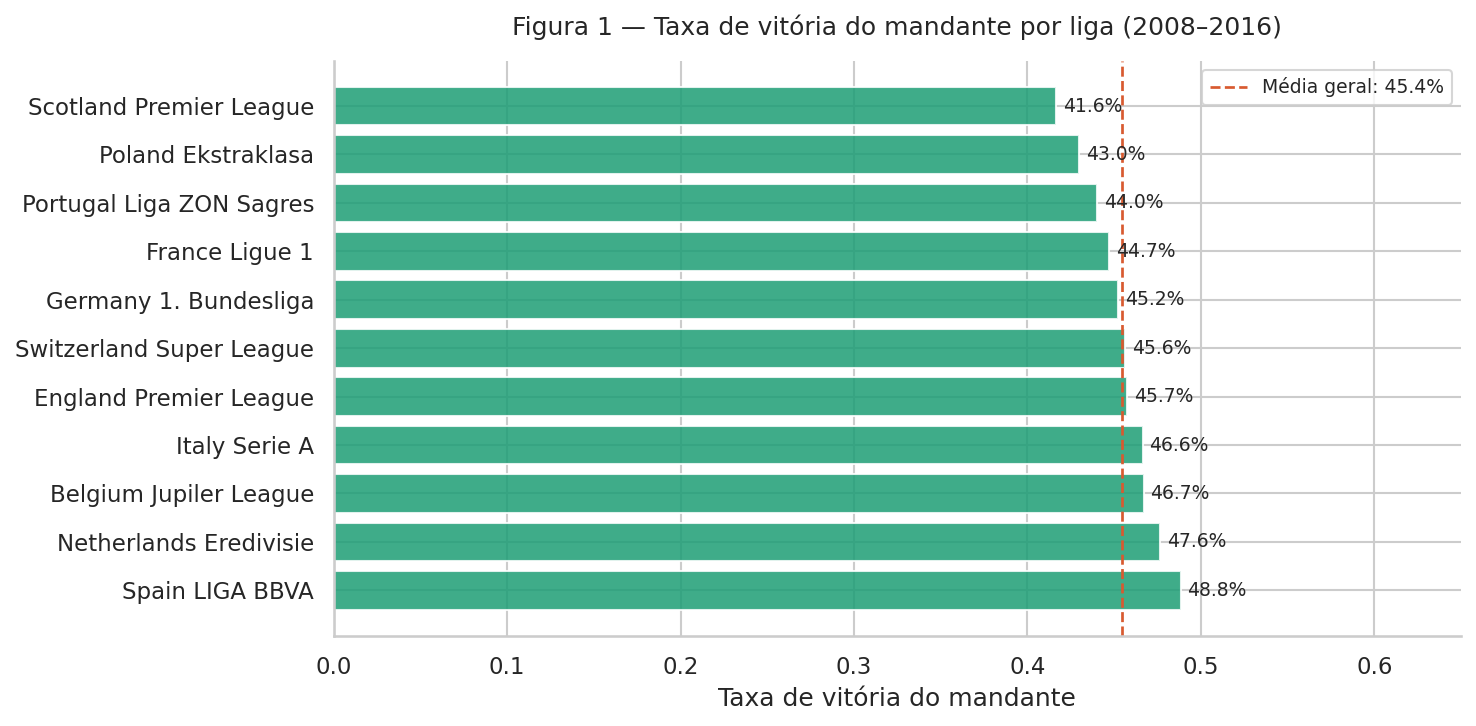

In [12]:
# ── Figura 1 — Taxa de vitória do mandante por liga ──────────────────────────

taxa = (
    df.groupby('league_name')['home_win']
    .agg(partidas='count', taxa='mean')
    .sort_values('taxa', ascending=False).reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(taxa['league_name'], taxa['taxa'], color='#1D9E75', alpha=0.85, edgecolor='white')
media = taxa['taxa'].mean()
ax.axvline(media, color='#D85A30', linestyle='--', linewidth=1.3,
           label=f'Média geral: {media:.1%}')
for bar, val in zip(bars, taxa['taxa']):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)
ax.set_xlabel('Taxa de vitória do mandante')
ax.set_title('Figura 1 — Taxa de vitória do mandante por liga (2008–2016)', pad=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 0.65)
sns.despine()
plt.tight_layout()
plt.savefig('g1_taxa_vitoria_liga.png', dpi=150, bbox_inches='tight')
plt.show()


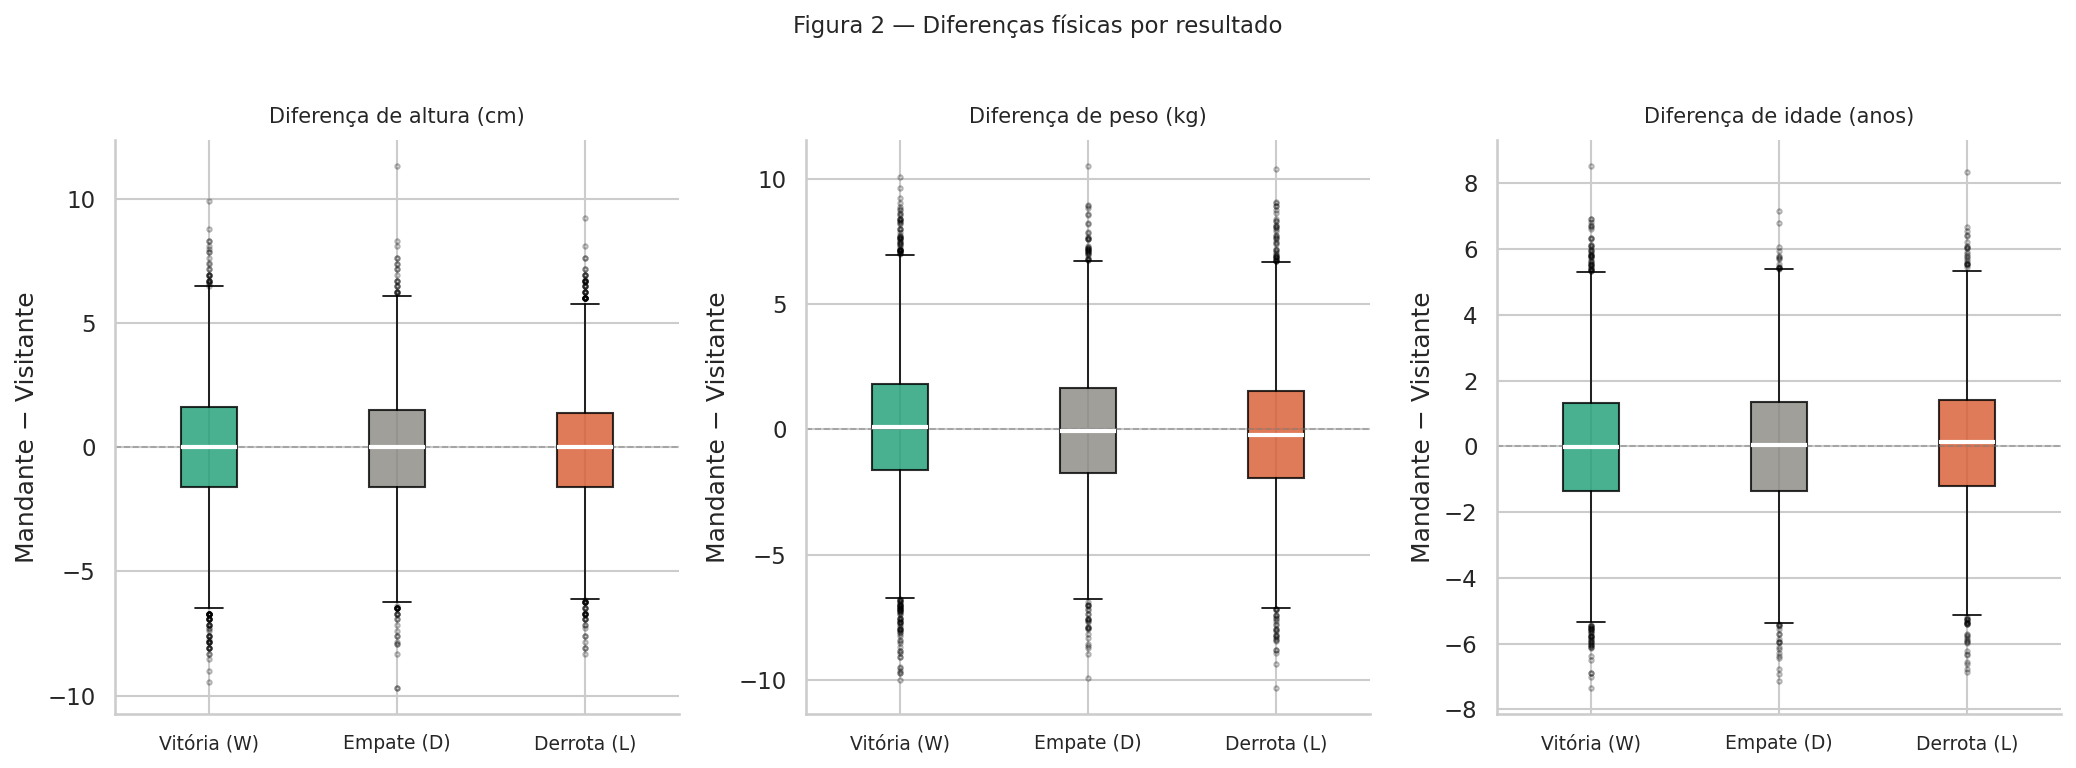

In [13]:
# ── Figura 2 — Boxplot das diferenças físicas por resultado ──────────────────

labels = {
    'diff_height': 'Diferença de altura (cm)',
    'diff_weight': 'Diferença de peso (kg)',
    'diff_age':    'Diferença de idade (anos)',
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, feat in zip(axes, features):
    dados = [df[df['result'] == r][feat].dropna() for r in ['W', 'D', 'L']]
    bp = ax.boxplot(dados, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, cor in zip(bp['boxes'], CORES_RESULTADO.values()):
        patch.set_facecolor(cor); patch.set_alpha(0.8)
    ax.set_xticklabels(['Vitória (W)', 'Empate (D)', 'Derrota (L)'], fontsize=9)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(labels[feat], fontsize=10, pad=8)
    ax.set_ylabel('Mandante − Visitante')
    sns.despine(ax=ax)

fig.suptitle('Figura 2 — Diferenças físicas por resultado', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('g2_boxplot_diferencas.png', dpi=150, bbox_inches='tight')
plt.show()


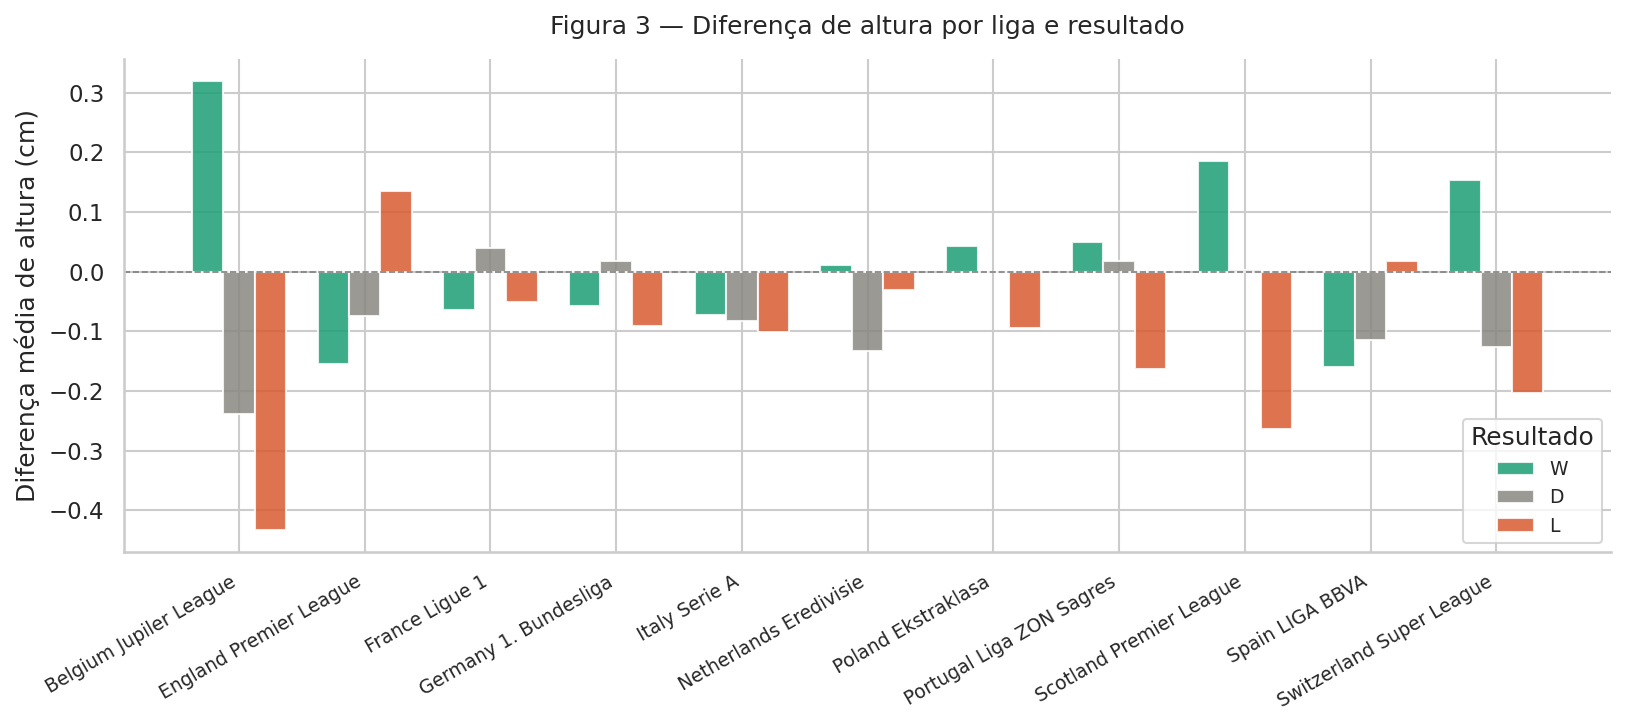

In [14]:
# ── Figura 3 — Diferença média de altura por liga e resultado ─────────────────

media_liga = (
    df.groupby(['league_name', 'result'])['diff_height']
    .mean().reset_index()
    .pivot(index='league_name', columns='result', values='diff_height')
)

fig, ax = plt.subplots(figsize=(11, 5))
x, width = range(len(media_liga)), 0.25
for i, (res, cor) in enumerate(CORES_RESULTADO.items()):
    ax.bar([p + i*width for p in x], media_liga[res], width, label=res, color=cor, alpha=0.85)
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(media_liga.index, rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylabel('Diferença média de altura (cm)')
ax.set_title('Figura 3 — Diferença de altura por liga e resultado', pad=12)
ax.legend(title='Resultado', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('g3_altura_liga_resultado.png', dpi=150, bbox_inches='tight')
plt.show()


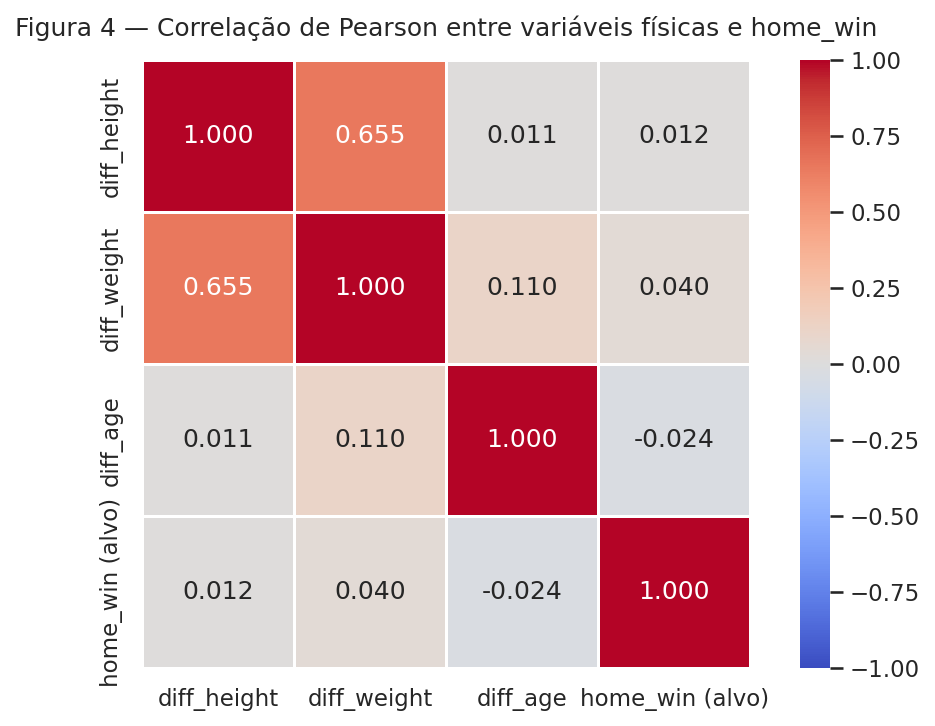

Correlação diff_height × diff_weight: 0.655


In [15]:
# ── Figura 4 — Heatmap de correlação de Pearson ───────────────────────────────

corr = df[features + ['home_win']].corr()
labels_corr = ['diff_height', 'diff_weight', 'diff_age', 'home_win (alvo)']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            xticklabels=labels_corr, yticklabels=labels_corr, ax=ax)
ax.set_title('Figura 4 — Correlação de Pearson entre variáveis físicas e home_win', pad=12)
plt.tight_layout()
plt.savefig('g4_heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlação diff_height × diff_weight:', corr.loc['diff_height', 'diff_weight'].round(3))


---
## Etapa 3 — Testes Estatísticos Formais

Cinco procedimentos para responder às perguntas centrais com rigor estatístico:

| # | Teste | Objetivo |
|:--|:------|:---------|
| 1 | **Teste t de Welch** | Compara médias de W vs L (sem assumir variâncias iguais) |
| 2 | **ANOVA one-way** | Estende a comparação aos três grupos W, D, L |
| 3 | **Correlação ponto-bisserial** | Associação entre cada variável física e `home_win` |
| 4 | **Correlação de Pearson** | Multicolinearidade entre as variáveis preditoras |
| 5 | **Testes estratificados por liga** | Responde diretamente à pergunta 2 |

Nível de significância: **α = 0,05** em todos os testes.


In [16]:
# ── Testes globais (Welch, ANOVA, ponto-bisserial) ───────────────────────────

W_df = df[df['result'] == 'W']
L_df = df[df['result'] == 'L']

resultados = []
for feat in features:
    t_stat, p_t  = stats.ttest_ind(W_df[feat].dropna(), L_df[feat].dropna(), equal_var=False)
    f_stat, p_a  = stats.f_oneway(
        df[df['result']=='W'][feat].dropna(),
        df[df['result']=='D'][feat].dropna(),
        df[df['result']=='L'][feat].dropna())
    r_pb, _      = stats.pointbiserialr(df['home_win'], df[feat].fillna(df[feat].mean()))
    resultados.append({
        'Variável':     feat,
        'Média W':      round(W_df[feat].mean(), 3),
        'Média L':      round(L_df[feat].mean(), 3),
        'p (t Welch)':  round(p_t, 5),
        'p (ANOVA)':    round(p_a, 5),
        'r ponto-bis.': round(r_pb, 4),
        'Sig. t':       'Sim' if p_t < 0.05 else 'Não',
        'Sig. ANOVA':   'Sim' if p_a < 0.05 else 'Não',
    })

print('── Resultados dos testes estatísticos globais ──')
print(pd.DataFrame(resultados).to_string(index=False))


── Resultados dos testes estatísticos globais ──
   Variável  Média W  Média L  p (t Welch)  p (ANOVA)  r ponto-bis. Sig. t Sig. ANOVA
diff_height   -0.016   -0.089      0.03925    0.11196        0.0124    Sim        Não
diff_weight    0.088   -0.204      0.00000    0.00000        0.0400    Sim        Sim
   diff_age   -0.018    0.120      0.00000    0.00003       -0.0237    Sim        Sim


In [17]:
# ── Testes por liga — responde à pergunta 2 ──────────────────────────────────

linhas = []
for liga in sorted(df['league_name'].unique()):
    sub = df[df['league_name'] == liga]
    W_s, L_s = sub[sub['result']=='W'], sub[sub['result']=='L']
    for feat in features:
        t, p = stats.ttest_ind(W_s[feat].dropna(), L_s[feat].dropna(), equal_var=False)
        linhas.append({'Liga': liga, 'Variável': feat,
                       't_stat': round(t, 3), 'p_value': round(p, 4),
                       'Sig.': 'Sim' if p < 0.05 else 'Não'})

testes_liga = pd.DataFrame(linhas)
pivot = testes_liga.pivot_table(index='Liga', columns='Variável', values='Sig.', aggfunc='first')
print('── Significância (Teste t de Welch, p < 0,05) por liga e variável ──')
print(pivot.to_string())


── Significância (Teste t de Welch, p < 0,05) por liga e variável ──
Variável                 diff_age diff_height diff_weight
Liga                                                     
Belgium Jupiler League        Sim         Sim         Sim
England Premier League        Sim         Sim         Sim
France Ligue 1                Não         Não         Sim
Germany 1. Bundesliga         Sim         Não         Não
Italy Serie A                 Sim         Não         Sim
Netherlands Eredivisie        Sim         Não         Não
Poland Ekstraklasa            Não         Não         Sim
Portugal Liga ZON Sagres      Sim         Não         Sim
Scotland Premier League       Não         Sim         Sim
Spain LIGA BBVA               Não         Não         Não
Switzerland Super League      Não         Sim         Sim


---
## Etapa 4 — Modelagem Supervisionada

Utilizamos apenas as três variáveis físicas (`diff_height`, `diff_weight`, `diff_age`)
como preditoras. Isso permite quantificar o poder preditivo do perfil físico **de forma isolada**,
sem interferência de outros fatores.

**Modelos:**
- **Regressão Logística** — principal, interpretável pelos coeficientes
- **Random Forest** (200 estimadores, `max_depth=6`) — complementar, captura não-linearidades

**Validação:** StratifiedKFold 5-fold, `random_state=42` (preserva proporção das classes em cada fold)  
**Métricas:** ROC-AUC (principal), Acurácia, F1-Score  

> O `StandardScaler` é aplicado **dentro de cada fold e de cada liga**, evitando vazamento de dados.


In [18]:
# ── Modelos globais ───────────────────────────────────────────────────────────

X = df[features].fillna(df[features].mean())
y = df['home_win']

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Regressão Logística': (LogisticRegression(max_iter=1000), X_sc),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, max_depth=6,
                                                   random_state=42, n_jobs=-1), X),
}

print(f'{'Modelo':<25} {'ROC-AUC':>14} {'Acurácia':>14} {'F1-Score':>14}')
print('-' * 67)
for nome, (m, Xi) in modelos.items():
    auc = cross_val_score(m, Xi, y, cv=skf, scoring='roc_auc')
    acc = cross_val_score(m, Xi, y, cv=skf, scoring='accuracy')
    f1  = cross_val_score(m, Xi, y, cv=skf, scoring='f1')
    print(f'{nome:<25} {auc.mean():.4f}±{auc.std():.4f}'
          f'  {acc.mean():.4f}±{acc.std():.4f}'
          f'  {f1.mean():.4f}±{f1.std():.4f}')


Modelo                           ROC-AUC       Acurácia       F1-Score
-------------------------------------------------------------------
Regressão Logística       0.5318±0.0085  0.5432±0.0021  0.1073±0.0149
Random Forest             0.5290±0.0073  0.5411±0.0040  0.0947±0.0220


   Variável  Coeficiente LR
diff_weight          0.1233
   diff_age         -0.0603
diff_height         -0.0551

   Variável  Importância RF
diff_weight          0.3814
   diff_age          0.3480
diff_height          0.2706


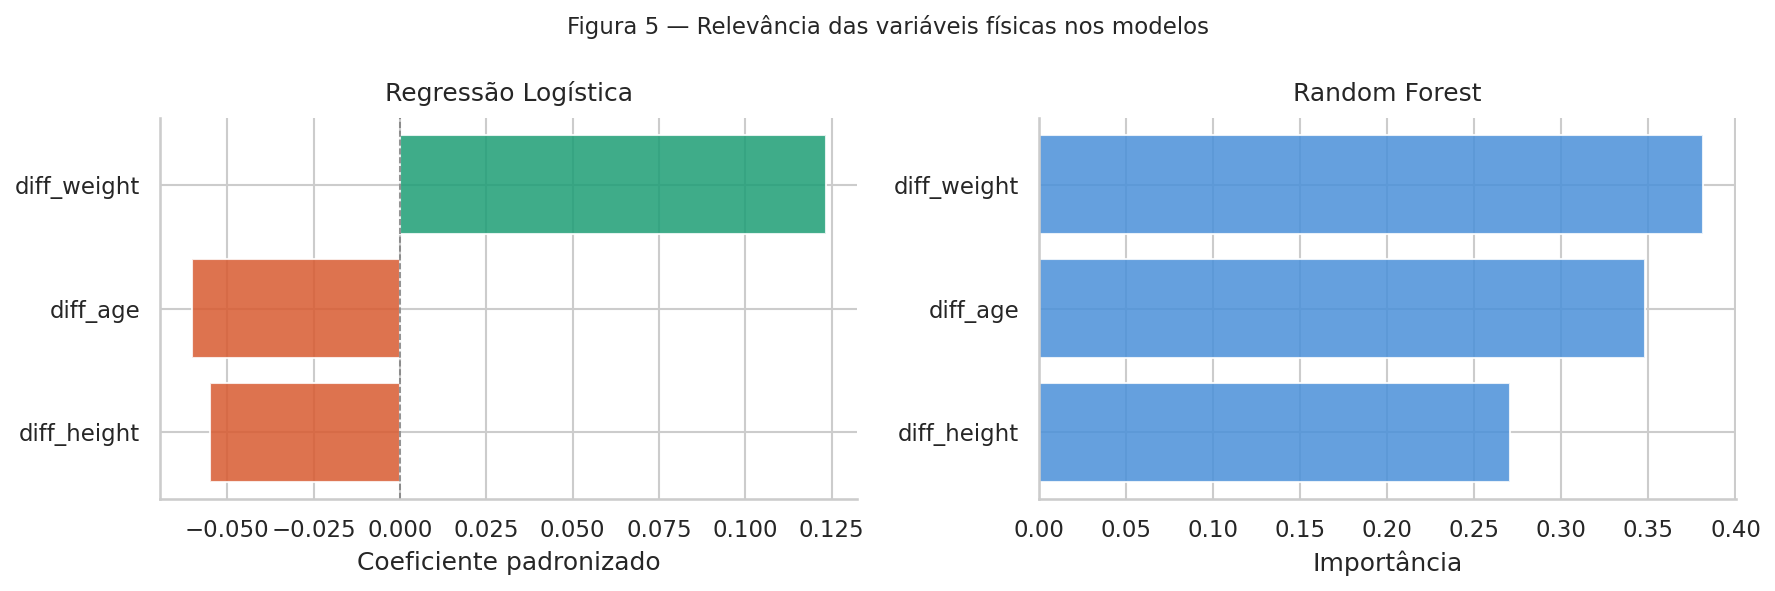

In [19]:
# ── Coeficientes e importâncias ───────────────────────────────────────────────

lr = LogisticRegression(max_iter=1000).fit(X_sc, y)
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1).fit(X, y)

coef_df = pd.DataFrame({'Variável': features, 'Coeficiente LR': lr.coef_[0].round(4)})
imp_df  = pd.DataFrame({'Variável': features, 'Importância RF': rf.feature_importances_.round(4)})
print(coef_df.sort_values('Coeficiente LR', key=abs, ascending=False).to_string(index=False))
print()
print(imp_df.sort_values('Importância RF', ascending=False).to_string(index=False))

# Figura 5
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coef_s = coef_df.sort_values('Coeficiente LR', key=abs, ascending=True)
cores_c = ['#1D9E75' if v > 0 else '#D85A30' for v in coef_s['Coeficiente LR']]
axes[0].barh(coef_s['Variável'], coef_s['Coeficiente LR'], color=cores_c, alpha=0.85)
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Coeficiente padronizado')
axes[0].set_title('Regressão Logística', pad=8)
sns.despine(ax=axes[0])

imp_s = imp_df.sort_values('Importância RF', ascending=True)
axes[1].barh(imp_s['Variável'], imp_s['Importância RF'], color='#4A90D9', alpha=0.85)
axes[1].set_xlabel('Importância')
axes[1].set_title('Random Forest', pad=8)
sns.despine(ax=axes[1])

fig.suptitle('Figura 5 — Relevância das variáveis físicas nos modelos', fontsize=11)
plt.tight_layout()
plt.savefig('g5_importancia.png', dpi=150, bbox_inches='tight')
plt.show()


── AUC-ROC por liga ──
                    Liga    n    AUC    Std
  Belgium Jupiler League 1497 0.5849 0.0384
Switzerland Super League 1315 0.5820 0.0351
 Scotland Premier League 1820 0.5628 0.0327
           Italy Serie A 3017 0.5625 0.0208
      Poland Ekstraklasa  840 0.5482 0.0261
  Netherlands Eredivisie 2232 0.5421 0.0509
         Spain LIGA BBVA 3039 0.5419 0.0280
Portugal Liga ZON Sagres 1901 0.5391 0.0300
   Germany 1. Bundesliga 2445 0.5353 0.0169
          France Ligue 1 3039 0.5301 0.0127
  England Premier League 3040 0.5250 0.0148


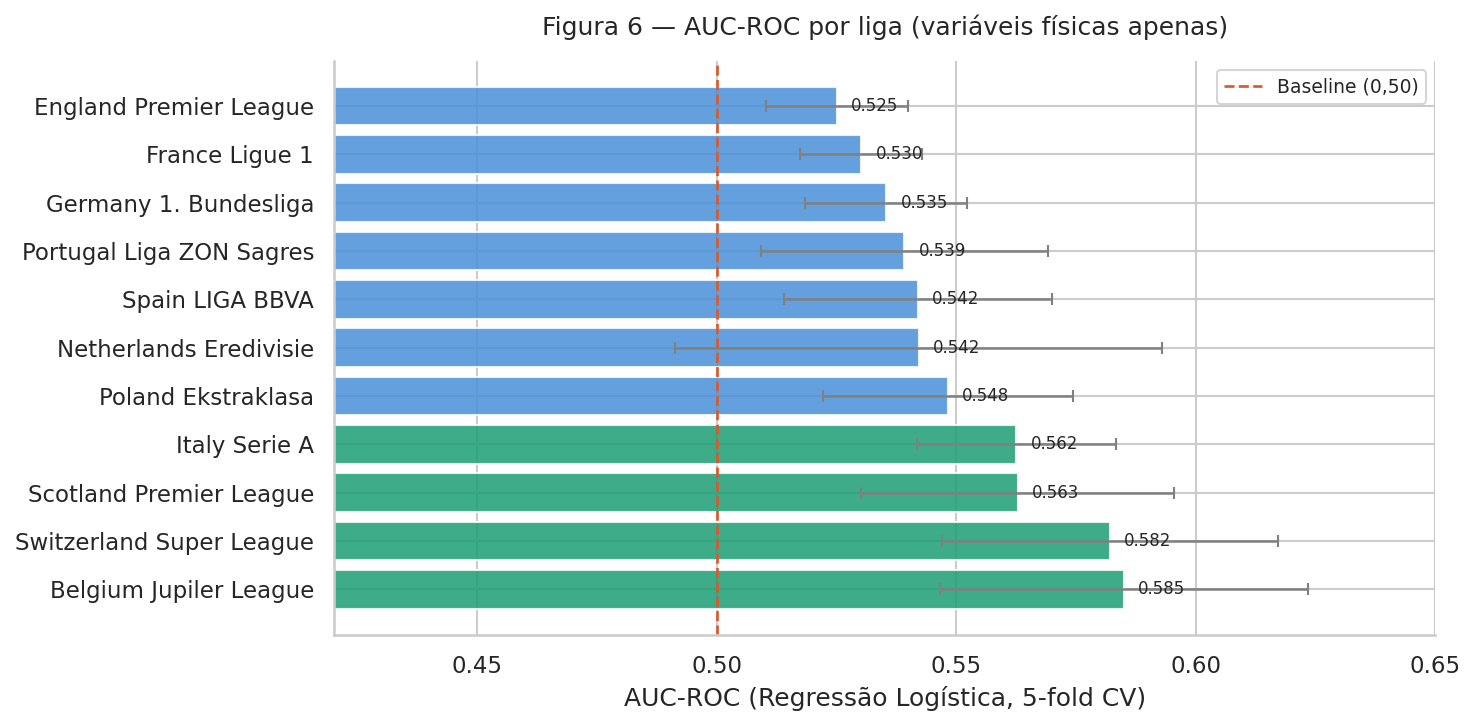

In [20]:
# ── ROC-AUC por liga (responde à pergunta 2 via modelagem) ───────────────────

auc_liga = []
for liga in sorted(df['league_name'].unique()):
    sub  = df[df['league_name'] == liga].copy()
    Xi   = sub[features].fillna(sub[features].mean())
    yi   = sub['home_win']
    if yi.nunique() < 2 or len(yi) < 50:
        continue
    Xsc  = StandardScaler().fit_transform(Xi)
    try:
        aucs = cross_val_score(
            LogisticRegression(max_iter=1000), Xsc, yi,
            cv=StratifiedKFold(5, shuffle=True, random_state=42),
            scoring='roc_auc')
        auc_liga.append({'Liga': liga, 'n': len(yi),
                         'AUC': round(aucs.mean(), 4), 'Std': round(aucs.std(), 4)})
    except Exception:
        pass

auc_df = pd.DataFrame(auc_liga).sort_values('AUC', ascending=False)
print('── AUC-ROC por liga ──')
print(auc_df.to_string(index=False))

# Figura 6
fig, ax = plt.subplots(figsize=(10, 5))
cores_a = ['#1D9E75' if v > 0.55 else '#4A90D9' if v > 0.52 else '#888780'
           for v in auc_df['AUC']]
ax.barh(auc_df['Liga'], auc_df['AUC'], color=cores_a, alpha=0.85)
ax.errorbar(auc_df['AUC'], auc_df['Liga'], xerr=auc_df['Std'],
            fmt='none', color='gray', linewidth=1.2, capsize=3)
ax.axvline(0.5, color='#D85A30', linestyle='--', linewidth=1.3, label='Baseline (0,50)')
for _, row in auc_df.iterrows():
    ax.text(row['AUC'] + 0.003, auc_df.index.get_loc(_), f"{row['AUC']:.3f}",
            va='center', fontsize=8)
ax.set_xlabel('AUC-ROC (Regressão Logística, 5-fold CV)')
ax.set_title('Figura 6 — AUC-ROC por liga (variáveis físicas apenas)', pad=12)
ax.legend(fontsize=9)
ax.set_xlim(0.42, 0.65)
sns.despine()
plt.tight_layout()
plt.savefig('g6_auc_por_liga.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Apêndice — Comparação: Modelo Físico vs. Modelo com Atributos FIFA

> Esta seção usa atributos **subjetivos** do simulador FIFA (`Player_Attributes`) e está fora do escopo principal.
> O objetivo é comparar o AUC do modelo físico com o de um modelo expandido que inclui variáveis FIFA,
> quantificando o ganho preditivo ao incorporar dados subjetivos.
>
> **Os resultados desta seção não integram as conclusões do trabalho.**


In [21]:
# Carrega atributos FIFA e calcula médias por jogador
conn = sqlite3.connect(DB_PATH)
pa = pd.read_sql("""
    SELECT player_api_id, overall_rating, stamina, strength
    FROM Player_Attributes
    WHERE overall_rating IS NOT NULL
""", conn)
conn.close()

pa_mean = pa.groupby('player_api_id').mean().reset_index()
print(f'Jogadores com atributos FIFA: {len(pa_mean):,}')
print(pa_mean[['overall_rating','stamina','strength']].describe().round(2))


Jogadores com atributos FIFA: 11,060
       overall_rating   stamina  strength
count        11060.00  11060.00  11060.00
mean            66.82     65.45     66.64
std              6.24     11.27     11.00
min             43.00     16.00     21.50
25%             62.82     60.08     60.09
50%             66.72     67.12     67.82
75%             70.95     72.87     74.26
max             92.19     93.18     95.00


In [22]:
# Reconstrói o dataset com atributos FIFA
# Usa o df_final já calculado na Etapa 1; faz novo join via lineups

# Para reproduzir a partir do CSV salvo:
df_base = pd.read_csv('etapa1_dataset_fisico.csv')

# Recarrega lineups com join de Player_Attributes
conn = sqlite3.connect(DB_PATH)
matches_raw = pd.read_sql("""
    SELECT id AS match_id,
           home_player_1, home_player_2, home_player_3, home_player_4, home_player_5,
           home_player_6, home_player_7, home_player_8, home_player_9, home_player_10, home_player_11,
           away_player_1, away_player_2, away_player_3, away_player_4, away_player_5,
           away_player_6, away_player_7, away_player_8, away_player_9, away_player_10, away_player_11
    FROM Match
""", conn)
conn.close()

home_cols = [f'home_player_{i}' for i in range(1, 12)]
away_cols = [f'away_player_{i}' for i in range(1, 12)]

home_long = matches_raw[['match_id'] + home_cols].melt(
    id_vars='match_id', value_vars=home_cols,
    var_name='slot', value_name='player_api_id')
home_long['side'] = 'home'

away_long = matches_raw[['match_id'] + away_cols].melt(
    id_vars='match_id', value_vars=away_cols,
    var_name='slot', value_name='player_api_id')
away_long['side'] = 'away'

lineups_ap = pd.concat([home_long, away_long], ignore_index=True)
lineups_ap = lineups_ap.dropna(subset=['player_api_id'])
lineups_ap['player_api_id'] = lineups_ap['player_api_id'].astype(int)

# Join com atributos FIFA
lineups_ap = lineups_ap.merge(pa_mean, on='player_api_id', how='left')

# Agrega por (match_id, side)
agg_ap = (
    lineups_ap.groupby(['match_id', 'side'])
    [['overall_rating', 'stamina', 'strength']]
    .mean().reset_index()
)

home_ap = agg_ap[agg_ap['side'] == 'home'].drop(columns='side')
away_ap = agg_ap[agg_ap['side'] == 'away'].drop(columns='side')
home_ap.columns = ['match_id', 'home_overall', 'home_stamina', 'home_strength']
away_ap.columns = ['match_id', 'away_overall', 'away_stamina', 'away_strength']

df_ap = df_base.merge(home_ap, on='match_id', how='left')
df_ap = df_ap.merge(away_ap, on='match_id', how='left')

# Variáveis de diferença FIFA
df_ap['diff_overall']  = (df_ap['home_overall']  - df_ap['away_overall']).round(3)
df_ap['diff_stamina']  = (df_ap['home_stamina']  - df_ap['away_stamina']).round(3)
df_ap['diff_strength'] = (df_ap['home_strength'] - df_ap['away_strength']).round(3)

# Remove linhas sem atributos FIFA
fifa_feats = ['diff_overall', 'diff_stamina', 'diff_strength']
df_ap_clean = df_ap.dropna(subset=fifa_feats).copy()
print(f'Partidas com atributos FIFA completos: {len(df_ap_clean):,}')


Partidas com atributos FIFA completos: 24,185


In [23]:
# Comparação: Modelo A (físico) vs Modelo B (físico + FIFA)

features_fisicas = ['diff_height', 'diff_weight', 'diff_age']
features_fifa    = ['diff_overall', 'diff_stamina', 'diff_strength']
features_combo   = features_fisicas + features_fifa

y_ap = df_ap_clean['home_win']
skf_ap = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_ap = {}
for nome, feats in [('Modelo A — Físico', features_fisicas),
                     ('Modelo B — Físico + FIFA', features_combo)]:
    X_ap = df_ap_clean[feats].fillna(df_ap_clean[feats].mean())
    X_sc = StandardScaler().fit_transform(X_ap)
    aucs = cross_val_score(LogisticRegression(max_iter=1000), X_sc, y_ap,
                           cv=skf_ap, scoring='roc_auc')
    resultados_ap[nome] = aucs
    print(f'{nome}: AUC = {aucs.mean():.4f} ± {aucs.std():.4f}')

delta = resultados_ap['Modelo B — Físico + FIFA'].mean() - resultados_ap['Modelo A — Físico'].mean()
print(f'\nΔ AUC (B − A) = {delta:+.4f}')
print('Interpretação: ganho ao incluir atributos FIFA sobre modelo exclusivamente físico.')


Modelo A — Físico: AUC = 0.5318 ± 0.0085
Modelo B — Físico + FIFA: AUC = 0.7082 ± 0.0061

Δ AUC (B − A) = +0.1764
Interpretação: ganho ao incluir atributos FIFA sobre modelo exclusivamente físico.
